In [1]:
import xarray as xr
import zarr
from pathlib import Path
import dask

import pandas as pd
import numpy as np

from minisom import MiniSom

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

import fsspec
fs = fsspec.filesystem("")

In [2]:
# Location coordinates
locations = {
    'cpt': (-33.72, 18.6),
    'jhb': (-26.1, 28.0),
    'abj': (5.45, -3.9),
    #'lua': (-8.994111, 13.439933)
}

names = {'cpt': 'Cape Town', 'jhb': 'Johannesburg', 'abj': 'Abidjan'}#, 'lua': 'Luanda'}
baseline_period = slice('1970', '1999')
recent_period = slice('1993', '2022')

In [3]:
loc = 'jhb' #cpt then  abj still (no more change)
ds = xr.open_zarr(f'data/{loc}.zarr')
ds = ds[['v10', 'u10', 'utci']]
ds['utci'] = ds['utci'] -273.15

#ds['ws'] = np.sqrt(ds['u10']**2 + ds['v10']**2)

In [4]:
ds.lat.values

array([-18.6 , -18.85, -19.1 , -19.35, -19.6 , -19.85, -20.1 , -20.35,
       -20.6 , -20.85, -21.1 , -21.35, -21.6 , -21.85, -22.1 , -22.35,
       -22.6 , -22.85, -23.1 , -23.35, -23.6 , -23.85, -24.1 , -24.35,
       -24.6 , -24.85, -25.1 , -25.35, -25.6 , -25.85, -26.1 , -26.35,
       -26.6 , -26.85, -27.1 , -27.35, -27.6 , -27.85, -28.1 , -28.35,
       -28.6 , -28.85, -29.1 , -29.35, -29.6 , -29.85, -30.1 , -30.35,
       -30.6 , -30.85, -31.1 , -31.35, -31.6 , -31.85, -32.1 , -32.35,
       -32.6 , -32.85, -33.1 , -33.35, -33.6 ])

In [5]:
utci_loc = ds.sel(lat = locations[loc][0], lon = locations[loc][1], method = 'nearest').utci.load()

In [6]:
baseline_utci = utci_loc.sel(time=baseline_period)
recent_utci = utci_loc.sel(time=recent_period)

baseline_heat_events = baseline_utci.where(baseline_utci >= baseline_utci.quantile(0.99, dim='time')).dropna(dim='time').time.values
recent_heat_events = recent_utci.where(recent_utci >= recent_utci.quantile(0.99, dim='time')).dropna(dim='time').time.values

In [7]:
heat_events = np.array(sum([list(recent_heat_events),list(baseline_heat_events)], []))
heat_events = np.unique(heat_events)

In [8]:
ds = ds.sel(time=heat_events)

In [9]:
data = np.stack([ds[var].values for var in ['v10', 'u10']], axis=-1)
data = np.nan_to_num(data, nan=0)

In [10]:
# Reshape to (time*lat*lon, var) for each variable
data_reshaped = data.reshape(-1, data.shape[-1])

# Scale each variable independently
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data_reshaped)

# Reshape back to original shape (time, lat, lon, var)
data_normalized = data_normalized.reshape(data.shape)
data_normalized.shape


(211, 61, 61, 2)

In [11]:
data_normalized = data_normalized.reshape(len(ds.time.values), 2*61*61)
data_normalized.shape

(211, 7442)

In [33]:
# 5 rows x 7 columns = 35 total nodes
som_shape = (2, 2)  # 5 rows, 5 columns
som = MiniSom(som_shape[0], som_shape[1], input_len=2*61*61, sigma=1.0, learning_rate=0.5)
som.random_weights_init(data_normalized)
som.train_random(data_normalized, 100000)  # Train for 1000 iterations

In [34]:
winning_nodes = np.array([som.winner(x) for x in data_normalized])

In [35]:
winning_nodes_ids = winning_nodes[:, 0] * som_shape[1] + winning_nodes[:, 1]

In [36]:
ds = ds.assign_coords(som_node=('time', winning_nodes_ids))

In [37]:
grouped = ds.groupby('som_node').mean(dim='time')

In [38]:
grouped = grouped.compute()

In [39]:
nodes = grouped.copy()
nodes = nodes.stack(space=('lat', 'lon'))

In [40]:
weights = som.get_weights().reshape(-1, 2)
weights = scaler.inverse_transform(weights)
weights = weights.reshape(-1, 61*61, 2)
weights.shape

(4, 3721, 2)

In [41]:

#nodes['utci'] = ('som_node', 'space'), weights[:, :, 0]
nodes['v10'] = ('som_node', 'space'), weights[:, :, 0]
nodes['u10'] = ('som_node', 'space'), weights[:, :, 1]
nodes = nodes.unstack('space')

In [42]:
nodes['ws'] = np.sqrt(nodes['u10']**2 + nodes['v10']**2)

In [43]:
#nodes['utci'] = grouped['utci'] #nodes['utci'].where(nodes['utci'] > 0)

In [44]:
del grouped
grouped = nodes.copy()

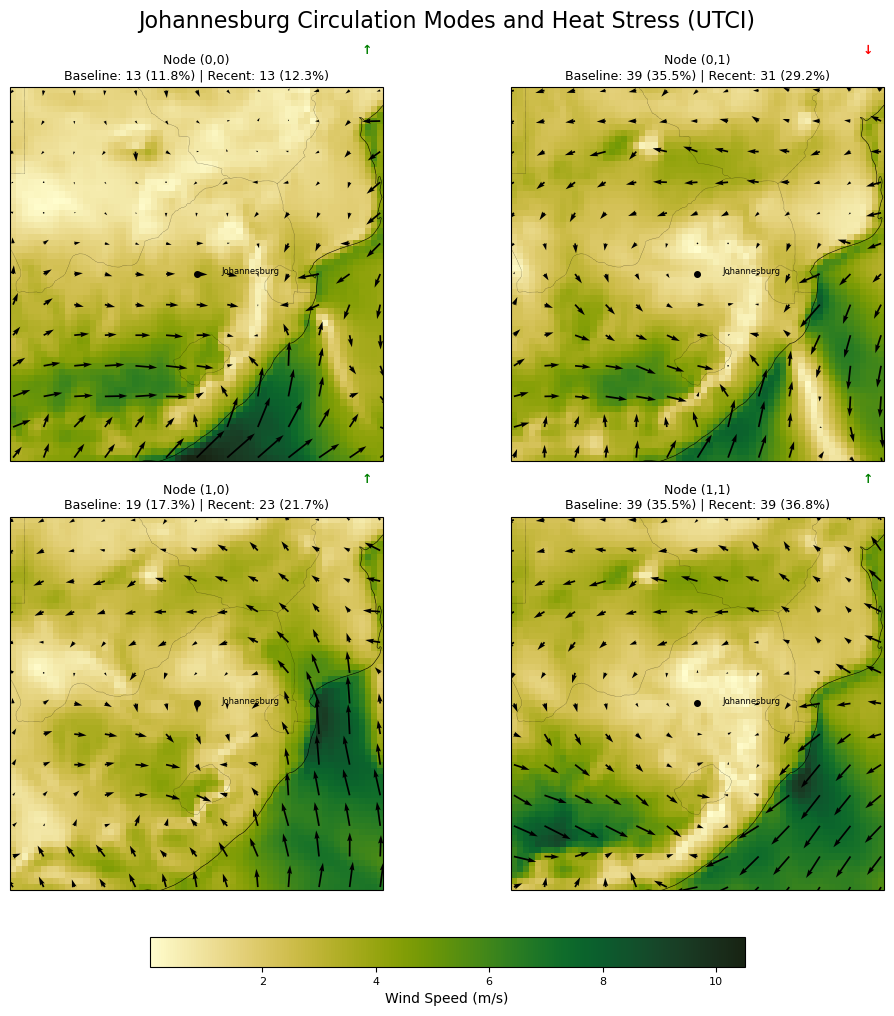

In [45]:
# Calculate node percentages for baseline and recent periods
baseline_values = [ds.som_node.sel(time=x).item() for x in baseline_heat_events]
recent_values = [ds.som_node.sel(time=x).item() for x in recent_heat_events]

baseline_unique, baseline_counts = np.unique(baseline_values, return_counts=True)
recent_unique, recent_counts = np.unique(recent_values, return_counts=True)

baseline_dict = dict(zip(baseline_unique, baseline_counts))
recent_dict = dict(zip(recent_unique, recent_counts))

# Calculate total counts for percentage calculation
baseline_total = len(baseline_heat_events)
recent_total = len(recent_heat_events)

# Create the plot with map projection and constrained layout
fig, axes = plt.subplots(
    nrows=som_shape[0],
    ncols=som_shape[1],
    figsize=(10, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

# Determine shared color scale
vmin = grouped.ws.min().item()
vmax = grouped.ws.max().item()

node_name = []
# Plot each node with UTCI as background and wind as quivers
for i, node in enumerate(sorted(grouped.som_node.values)):
    ax = axes[i]
    
    # Calculate row and column position
    row = i // som_shape[1]
    col = i % som_shape[1]
    node_name.append(f'Node ({row},{col})')
    
    # Calculate percentages for this node
    baseline_count = baseline_dict.get(node, 0)
    recent_count = recent_dict.get(node, 0)
    
    baseline_pct = (baseline_count / baseline_total) * 100 if baseline_total > 0 else 0
    recent_pct = (recent_count / recent_total) * 100 if recent_total > 0 else 0
    
    # Calculate percentage change
    if baseline_pct > 0:
        pct_change = ((recent_pct - baseline_pct) / baseline_pct) * 100
    else:
        pct_change = float('inf') if recent_pct > 0 else 0
    
    # Plot UTCI
    im = grouped.ws.sel(som_node=node).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.speed,  # perceptually uniform
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        add_labels=False
    )

    # Add wind quiver arrows (subsampled)
    step = 5
    ax.quiver(
        grouped.lon[::step],
        grouped.lat[::step],
        grouped.u10.sel(som_node=node)[::step, ::step],
        grouped.v10.sel(som_node=node)[::step, ::step],
        transform=ccrs.PlateCarree(),
        scale=100,
        color='black'
    )

    # Enhanced title with percentages and color coding
    if pct_change == float('inf'):
        change_text = 'New'
        change_color = 'orange'
    else:
        # Color-coded percentage change
        if pct_change > 0:
            change_color = 'green'
            change_text = f'↑'#{pct_change:+.1f}%'
        elif pct_change < 0:
            change_color = 'red'
            change_text = f'↓'#{pct_change:+.1f}%'
        else:
            change_color = 'gray'
            change_text = f'.'#{pct_change:+.1f}%'
    
    # Simpler approach - create title as formatted string with change colored
    title = f'Node ({row},{col})\nBaseline: {baseline_count} ({baseline_pct:.1f}%) | Recent: {recent_count} ({recent_pct:.1f}%) | {change_text}'
    
    # Set title but then override just the change part with color
    ax.set_title(f'Node ({row},{col})\nBaseline: {baseline_count} ({baseline_pct:.1f}%) | Recent: {recent_count} ({recent_pct:.1f}%)', fontsize=9)
    
    # Position the colored change text at the end of the second line
    ax.text(0.97, 1.1, change_text, transform=ax.transAxes, 
            fontsize=9, ha='right', va='center', color=change_color, weight='bold')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")


    key = loc
    lat, lon = locations[loc]
    ax.plot(lon, lat, marker='o', color='black', markersize=4, transform=ccrs.PlateCarree())
    ax.text(lon + 1, lat, names[key], fontsize=6, color='black', transform=ccrs.PlateCarree())

# Add shared colorbar at the bottom
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    shrink=0.6,
    pad=0.05
)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Wind Speed (m/s)', fontsize=10)

# Add a figure title
fig.suptitle(f'{names[loc]} Circulation Modes and Heat Stress (UTCI)', fontsize=16)

plt.savefig(f'plots/{loc}_som.png', dpi=300)

plt.show()

In [46]:
values = [ds.som_node.sel(time=x).item() for x in baseline_heat_events]
unique, counts = np.unique(values, return_counts=True)
counts = dict(zip(unique, counts))
baseline_counts = {int(k): int(v) for k, v in counts.items()}
baseline_counts


{0: 13, 1: 39, 2: 19, 3: 39}

In [47]:
values = [ds.som_node.sel(time=x).item() for x in recent_heat_events]
unique, counts = np.unique(values, return_counts=True)
counts = dict(zip(unique, counts))
recent_counts = {int(k): int(v) for k, v in counts.items()}
recent_counts

{0: 13, 1: 31, 2: 23, 3: 39}

In [55]:
baseline_color = 'teal' 
recent_color = 'darkorange' 

ValueError: max() iterable argument is empty

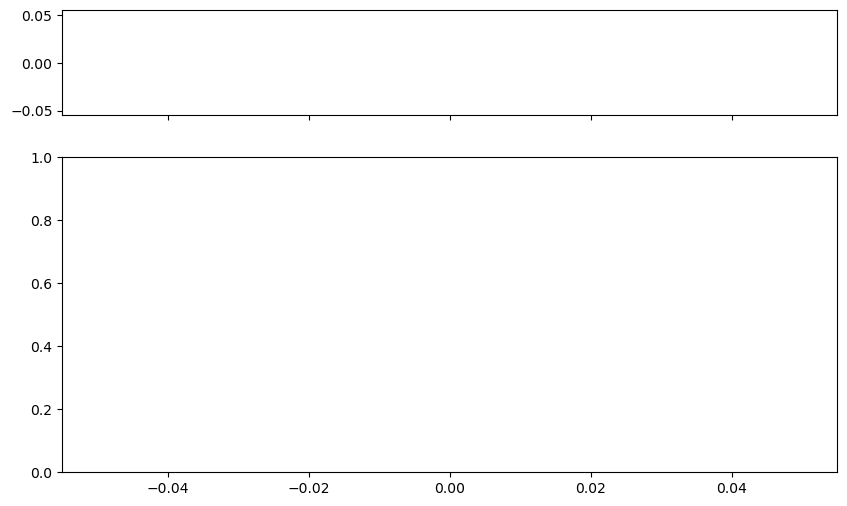

In [56]:
path = 'data/'
var = 'UTCI'
baseline_time = slice('1970', '1999')
recent_time = slice('1993', '2022')

da = ds.sel(lat=locations[loc][0], lon=locations[loc][1], method='nearest').utci

baseline_99 = da.sel(time=baseline_time).quantile(0.99, dim='time').compute()
recent_99 = da.sel(time=recent_time).quantile(0.99, dim='time').compute()

baseline_ext = da.sel(time=baseline_time).where(da.sel(time=baseline_time) > baseline_99).dropna(dim='time')
recent_ext = da.sel(time=recent_time).where(da.sel(time=recent_time) > recent_99).dropna(dim='time')

baseline_ext_counts = pd.Series(baseline_ext.som_node.values).value_counts().sort_index()
recent_ext_counts = pd.Series(recent_ext.som_node.values).value_counts().sort_index()

baseline_all_counts = pd.Series(da.sel(time=baseline_time).som_node.values).value_counts().sort_index()
recent_all_counts = pd.Series(da.sel(time=recent_time).som_node.values).value_counts().sort_index()

all_nodes = sorted(set(baseline_all_counts.index).union(recent_all_counts.index))

filtered_nodes = [n for n in all_nodes if baseline_ext_counts.get(n, 0) > 1 or recent_ext_counts.get(n, 0) > 1]

baseline_ext_freq = [baseline_ext_counts.get(n, 0) for n in filtered_nodes]
recent_ext_freq = [recent_ext_counts.get(n, 0) for n in filtered_nodes]

baseline_all_freq = [baseline_all_counts.get(n, 0) for n in filtered_nodes]
recent_all_freq = [recent_all_counts.get(n, 0) for n in filtered_nodes]

width = 0.35
x = np.arange(len(filtered_nodes))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,6), gridspec_kw={'height_ratios':[1,3]})

# Define y-axis limits for the two plots (adjust as needed)
# ax1 is the "upper" plot (for larger frequencies - all days)
# ax2 is the "lower" plot (for smaller frequencies - extreme days)

# Upper plot: frequencies for all days (unfilled bars)
ax1.bar(x - width/2, baseline_all_freq, width, edgecolor=baseline_color, fill=False, linewidth=1.5, label='All Days Baseline')
ax1.bar(x + width/2, recent_all_freq, width, edgecolor=recent_color, fill=False, linewidth=1.5, label='All Days Recent')

ax1.set_ylim(100, max(max(baseline_all_freq), max(recent_all_freq)) * 1.1)  # adjust lower limit to create the break effect
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax1.set_ylabel('Frequency (all days)')

# Lower plot: frequencies for extreme days (filled bars)
ax2.bar(x - width/2, baseline_ext_freq, width, color=baseline_color, label='> Threshold Baseline')
ax2.bar(x + width/2, recent_ext_freq, width, color=recent_color, label='> Threshold Recent')

ax2.set_ylim(0, max(max(baseline_ext_freq), max(recent_ext_freq)) * 1.1)
ax2.spines['top'].set_visible(False)
ax2.set_xlabel('SOM Node')
ax2.set_ylabel('Frequency (days above threshold)')

ax2.set_xticks(x)
ax2.set_xticklabels([node_name[i] for i in filtered_nodes], rotation=45)

# Add diagonal break marks
d = .01  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, loc='right')

plt.suptitle(f'Change in SOM Node Frequencies - {names[loc]}')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"plots/{loc}_som_node_shift_57.png")
plt.show()


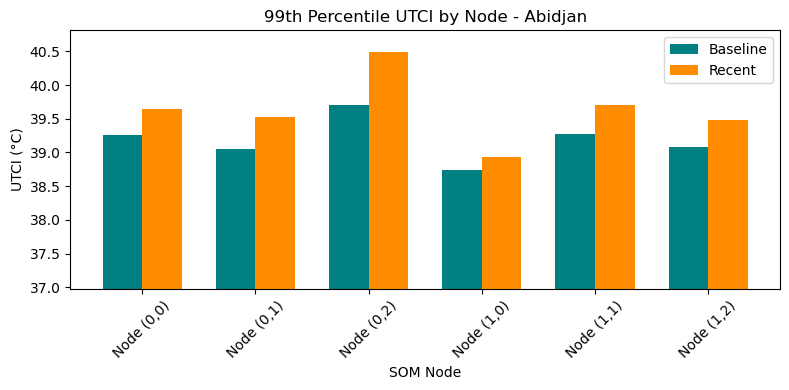

In [ ]:
path = '../create_analysis_dataset/data/'
path = 'data/'
var = 'UTCI'  # Can be changed to 'UTCI' or other heat indices
baseline_time = slice('1970', '1999')
recent_time = slice('1993', '2022')

# Get UTCI data for the location
da = ds.sel(lat = locations[loc][0], lon = locations[loc][1], method = 'nearest').utci

# Group data by SOM nodes first
baseline = da.sel(time = baseline_time)
baseline_by_node = baseline.groupby('som_node')
baseline_99_by_node = baseline_by_node.quantile(0.99, dim='time').compute()

recent = da.sel(time = recent_time)
recent_by_node = recent.groupby('som_node')
recent_99_by_node = recent_by_node.quantile(0.99, dim='time').compute()

# Get counts of days above node-specific thresholds
baseline_above = baseline.groupby('som_node').map(
    lambda x: x.where(x > x.quantile(0.99, dim='time'))
).dropna(dim='time')
baseline_counts = pd.Series(baseline_above.som_node.values).value_counts().sort_index()

recent_above = recent.groupby('som_node').map(
    lambda x: x.where(x > x.quantile(0.99, dim='time'))
).dropna(dim='time')
recent_counts = pd.Series(recent_above.som_node.values).value_counts().sort_index()

width = 0.35
x = np.arange(len(filtered_nodes))  # consecutive x positions for bars

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, [baseline_99_by_node.sel(som_node=n).item() for n in filtered_nodes], 
      width, label='Baseline', color=baseline_color)
ax.bar(x + width/2, [recent_99_by_node.sel(som_node=n).item() for n in filtered_nodes], 
      width, label='Recent', color=recent_color)

ax.set_xlabel('SOM Node')
ax.set_ylabel('UTCI (°C)')
ax.set_title(f'99th Percentile UTCI by Node - {names[loc]}')

ax.set_xticks(x)
ax.set_xticklabels([node_name[i] for i in filtered_nodes], rotation=45)

data_min = min(baseline_99_by_node.min(), recent_99_by_node.min())
data_max = max(baseline_99_by_node.max(), recent_99_by_node.max())

# Add some padding to y-limits
padding = (data_max - data_min) * 0.1
ax.set_ylim(data_min - padding, data_max + padding)

ax.legend()
plt.tight_layout()
plt.savefig(f"plots/{loc}_som_node_shift_99_57.png")
plt.show()

In [ ]:
node_name_filtered = [node_name[x] for x in filtered_nodes]

In [58]:
grouped = grouped.sel(som_node = filtered_nodes)

num_plots = len(filtered_nodes)

# Make layout wide rather than square
cols = min(som_shape[1], len(filtered_nodes)) # Use whichever is bigger
rows = math.ceil(num_plots / cols)  # Calculate required rows

# Size per subplot
width_per_plot = 4
height_per_plot = 4

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(width_per_plot * cols, height_per_plot * rows),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()

# Determine shared color scale
vmin = grouped.utci.min().item()
vmax = grouped.utci.max().item()

# Plot each node with UTCI as background and wind as quivers
for i, node in enumerate(sorted(grouped.som_node.values)):
    ax = axes[i]
    # Plot UTCI
    im = grouped.utci.sel(som_node=node).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.thermal,  # perceptually uniform
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        add_labels=False
    )

    # Add wind quiver arrows (subsampled)
    step = 5
    ax.quiver(
        grouped.lon[::step],
        grouped.lat[::step],
        grouped.u10.sel(som_node=node)[::step, ::step],
        grouped.v10.sel(som_node=node)[::step, ::step],
        transform=ccrs.PlateCarree(),
        scale=100,
        color='black'
    )

    ax.set_title(f'{node_name_filtered[i]}', fontsize=10)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")


    key = loc
    lat, lon = locations[loc]
    ax.plot(lon, lat, marker='o', color='black', markersize=4, transform=ccrs.PlateCarree())
    ax.text(lon + 1, lat, names[key], fontsize=6, color='black', transform=ccrs.PlateCarree())

# Add shared colorbar at the bottom
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    shrink=0.6,
    pad=0.05
)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('UTCI (°C)', fontsize=10)

# Remove unused axes completely
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# Add a figure title
fig.suptitle(f'{names[loc]} Circulation Modes and Heat Stress (UTCI)', fontsize=16)

plt.savefig(f'plots/{loc}_som_filtered_57.png', dpi=300, bbox_inches='tight')
plt.show()

ZeroDivisionError: division by zero